# Geocalibration 

This notebook is an attempt to use both the iterative kabsch algorithm and BFGS to search $q^r_{r'}$ and $q^m_c$

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize
import itertools
from tqdm import tqdm
from typing import List

In [2]:
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])

def get_zl_zr(f_str:str, data:pd.DataFrame):
    """
    Extract the data for focus [f_str] for ZL and ZR cameras
    f_str: str, string of the focus number
    data: pd.DataFrame, the data
    """
    d_left = data[data["cam"]==f"ZL{f_str}"].copy().reset_index(drop=True)
    d_right = data[data["cam"]==f"ZR{f_str}"].copy().reset_index(drop=True)
    return d_left, d_right

def parse_cahvor(z_data:pd.DataFrame):
  """
  return the data with the cahvor parameters parsed
  """
  z_data["c_r_vec"] = z_data["c_r_est"].apply(to_vec_space)
  z_data["h_r_vec"] = z_data["h_r_est"].apply(to_vec_space)
  z_data["v_r_vec"] = z_data["v_r_est"].apply(to_vec_space)
  z_data["a_r_vec"] = z_data["a_r_est"].apply(to_vec_space)
  z_data["R_rpm_mat"] = z_data["R_rpm"].apply(to_mat)
  z_data["t_rpm_vec"] = z_data["t_rpm"].apply(to_vec_comma)

def get_fl(idx:int, data_:np.ndarray,
           left_fl0:float, left_fl1:float,
           right_fl0:float, right_fl1:float)->float:
  """
  Calculates the focal length using above linear model
  """
  fmc = data_["fmc"][idx]
  if (data_["cam"][idx][1] == "L"):
    return left_fl0 + left_fl1 * fmc
  elif (data_["cam"][idx][1] == "R"):
    return right_fl0 + right_fl1 * fmc

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_KC(idx:int, data_:np.ndarray,
           left_fl0:float, left_fl1:float,
           right_fl0:float, right_fl1:float)->np.ndarray:
  """
  Forms the Kc matrix for that idx
  """
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_, left_fl0, left_fl1, right_fl0, right_fl1)
  Kc = np.array([[fl+b1, b2, cx],
               [0, fl, cy],
               [0, 0, 1]])
  return Kc

def get_KC_inv(idx:int, data_:np.ndarray,
          left_fl0:float, left_fl1:float,
          right_fl0:float, right_fl1:float)->np.ndarray:
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_, left_fl0, left_fl1, right_fl0, right_fl1)
  kc_inv = np.array([[1/(fl+b1), -b2/(fl*(fl+b1)), ((cy*b2)/(fl*(fl+b1)) - cx/(fl+b1))],
                     [0, 1/fl, -cy/fl],
                     [0, 0, 1]])
  return kc_inv

def get_H_r_data(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Form the H matrix from the ground truth data
  """
  h_i = np.expand_dims(data_["h_r_vec"][idx], axis=1)
  v_i = np.expand_dims(data_["v_r_vec"][idx], axis=1)
  a_i = np.expand_dims(data_["a_r_vec"][idx], axis=1)
  H_i = np.concatenate([h_i, v_i, a_i], axis=1)

  return H_i

In [148]:
f_str = "079"

data_fpath = "data/m41_site_cal_v229_v4.xlsx"
data_all = pd.read_excel(data_fpath)
outlier_removed = False

# parse data into left and right cam
zl, zr = get_zl_zr(f_str, data_all)

# parse cahvor vectors
parse_cahvor(zl)
parse_cahvor(zr)

# outlier removal
zl_outlier_idx = []
zr_outlier_idx = []
if not outlier_removed:
  zl = zl.drop(zl_outlier_idx).reset_index(drop=True)
  zr = zr.drop(zr_outlier_idx).reset_index(drop=True)
  outlier_removed = True

print('-'*75)
print(f"Number of data points for zl{f_str}:\t{zl.shape[0]}")
print(f"Number of data points for zr{f_str}:\t{zr.shape[0]}")

---------------------------------------------------------------------------
Number of data points for zl079:	86
Number of data points for zr079:	168


## Kabsch Algorithm

In [149]:
# Functions for Iterative Kabsch algorithm fits and plots
def solve_r_mc(data_, rot_rrp, lambda_h, lambda_v, lambda_a):
  R_rrp = rot_rrp.as_matrix()

  m_frame, c_frame = [], []
  for i in range(data_.shape[0]):
    # compute h^m from hr
    hr = get_H_r_data(i, data_)
    R_rpm = get_R_rpm(i, data_)
    
    scaled_hm = (R_rrp @ R_rpm).T @ hr @ np.diag([lambda_h, lambda_v, lambda_a])
    m_frame.append(list(scaled_hm[:,0]))
    m_frame.append(list(scaled_hm[:,1]))
    m_frame.append(list(scaled_hm[:,2]))

    # compute hm from hc
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = np.array([[fl+b1, 0, 0],
        [b2, fl, 0],
        [cx, cy, 1]])
    scaled_hc = hc @ np.diag([lambda_h, lambda_v, lambda_a])
    c_frame.append(scaled_hc[:,0])
    c_frame.append(scaled_hc[:,1])
    c_frame.append(scaled_hc[:,2])

  m_frame_arr = np.array(m_frame)
  c_frame_arr = np.array(c_frame)

  rot_mc, rssd = R.align_vectors(m_frame_arr, c_frame_arr, return_sensitivity=False)

  return rot_mc, rssd

def solve_r_rrp(data_, rot_mc, lambda_h, lambda_v, lambda_a):

  R_mc = rot_mc.as_matrix()

  r_frame, rp_frame = [], []
  for i in range(data_.shape[0]):
    # compute Hr
    hr = get_H_r_data(i, data_)
    scaled_hr = hr @ np.diag([lambda_h, lambda_v, lambda_a])
    r_frame.append(list(scaled_hr[:,0]))
    r_frame.append(list(scaled_hr[:,1]))
    r_frame.append(list(scaled_hr[:,2]))

    # compute hc
    R_rpm = get_R_rpm(i, data_)
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = np.array([[fl+b1, 0, 0],
                  [b2, fl, 0],
                  [cx, cy, 1]])
    scaled_hrp = R_rpm @ R_mc @ hc @ np.diag([lambda_h, lambda_v, lambda_a])
    rp_frame.append(list(scaled_hrp[:,0]))
    rp_frame.append(list(scaled_hrp[:,1]))
    rp_frame.append(list(scaled_hrp[:,2]))

  r_frame_arr = np.array(r_frame)
  rp_frame_arr = np.array(rp_frame)

  rot_rrp, rssd = R.align_vectors(r_frame_arr, rp_frame_arr, return_sensitivity=False)
  
  return rot_rrp, rssd

def compute_rel_err(data_, rot_rrp, rot_mc):
  # compute the relative error
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()

  rel_h_err, rel_v_err, rel_a_err = 0, 0, 0
  for i in range(data_.shape[0]):
    Hr = get_H_r_data(i, data_)
    h_r, v_r, a_r = np.expand_dims(Hr[:,0], axis=1), np.expand_dims(Hr[:,1], axis=1), np.expand_dims(Hr[:,2], axis=1)

    R_rpm = get_R_rpm(i, data_)
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    Hc = np.array([[fl+b1, 0, 0],
                  [b2, fl, 0],
                  [cx, cy, 1]])
    h_c, v_c, a_c = np.expand_dims(Hc[:,0], axis=1), np.expand_dims(Hc[:,1], axis=1), np.expand_dims(Hc[:,2], axis=1)

    rel_h_err += np.linalg.norm(h_r - R_rrp @ R_rpm @ R_mc @ h_c)/np.linalg.norm(h_r)
    rel_v_err += np.linalg.norm(v_r - R_rrp @ R_rpm @ R_mc @ v_c)/np.linalg.norm(v_r)
    rel_a_err += np.linalg.norm(a_r - R_rrp @ R_rpm @ R_mc @ a_c)/np.linalg.norm(a_r)

  return rel_h_err, rel_v_err, rel_a_err

def plot_hr(data_, rot_rrp, rot_mc, fstr):
  hr_data_left, hr_model_left = [], []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    hr_data_left.append(get_H_r_data(i, data_))

    # compute Hc from model
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)
    hr_model_left.append(R_rrp @ R_rpm @ R_mc @ hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_data_left], label="$H^r$")
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_model_left], 
                      marker="x", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  ax[0,2].legend(bbox_to_anchor=(1.1, 1))
  fig.suptitle(f"$H^r$ for {fstr}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

def plot_hr_res(data_, rot_rrp, rot_mc, fstr):
  hr_res = []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr = get_H_r_data(i, data_)

    # compute Hc from model
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)
    
    # compute res
    hr_res.append(Hr - R_rrp @ R_rpm @ R_mc @ hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_res],
                      marker='.', color='red')
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}] Res")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  fig.suptitle(f"$H^r$ fit residuals for {fstr}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

def plot_hr_rel_err(data_, rot_rrp, rot_mc, fstr):
  hr_rel_err, ar_rel_err, vr_rel_err = [], [], []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr_data = get_H_r_data(i, data_)

    # compute Hc from model
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)
    Hr_compute = R_rrp @ R_rpm @ R_mc @ hc
    
    # compute res
    hr_rel_err.append(np.linalg.norm(Hr_data[:,0]-Hr_compute[:,0])/np.linalg.norm(Hr_data[:,0]))
    vr_rel_err.append(np.linalg.norm(Hr_data[:,1]-Hr_compute[:,1])/np.linalg.norm(Hr_data[:,1]))
    ar_rel_err.append(np.linalg.norm(Hr_data[:,2]-Hr_compute[:,2])/np.linalg.norm(Hr_data[:,2]))

  # plot
  fig, ax = plt.subplots(1, 3, figsize=(9,3))
  ax[0].scatter(data_["fmc"], hr_rel_err, marker='.', color='red')
  ax[0].set_xlabel("fmc", fontweight="bold")
  ax[0].set_title("$h^r$ rel error", fontweight="bold")
  ax[0].grid(linestyle="--", alpha=0.6)

  ax[1].scatter(data_["fmc"], vr_rel_err, marker='.', color='red')
  ax[1].set_xlabel("fmc", fontweight="bold")
  ax[1].set_title("$v^r$ rel error", fontweight="bold")
  ax[1].grid(linestyle="--", alpha=0.6)

  ax[2].scatter(data_["fmc"], ar_rel_err, marker='.', color='red')
  ax[2].set_xlabel("fmc", fontweight="bold")
  ax[2].set_title("$a^r$ rel error", fontweight="bold")
  ax[2].grid(linestyle="--", alpha=0.6)


  fig.suptitle(f"$H^r$ relative errors for {fstr}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax


# Functions for BFGS fits and plots
def gen_obj(data_, q_rrp):
  data__ = data_.copy()
  R_rrp = R.from_quat(q_rrp).as_matrix()

  # objective function to minimize over
  def obj(x:List):
    rot_mc_0 = R.from_quat(x[:4])
    rot_mc_1 = R.from_quat(x[4:8])

    total_cost = 0
    for i in range(data__.shape[0]):
      # H^r matrix
      Hr = get_H_r_data(i, data__)

      # H^c matrix
      fl, b1, b2, cx, cy = data__[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
      Hc = [[fl+b1, 0, 0],
            [b2, fl, 0],
            [cx, cy, 1]]
      

      # rotation matrices
      R_rpm = get_R_rpm(i, data__)
      f = data__["fmc"][i]
      R_mc = (rot_mc_0 * (rot_mc_1**(f/1000))).as_matrix()
      

      # Errors
      err = (Hr - R_rrp @ R_rpm @ R_mc @ Hc)
      total_cost += np.linalg.norm(err[:,0])**2 / np.linalg.norm(Hr[:,0])**2
      total_cost += np.linalg.norm(err[:,1])**2 / np.linalg.norm(Hr[:,1])**2
      total_cost += np.linalg.norm(err[:,2])**2 / np.linalg.norm(Hr[:,2])**2

      return total_cost
  
  return obj

def plot_qmc_hr_rel_err(data_, q_rrp, q_mc_0, q_mc_1):
  rot_rrp = R.from_quat(q_rrp)
  rot_mc_zl_0 = R.from_quat(q_mc_0)
  rot_mc_zl_1 = R.from_quat(q_mc_1)

  hr_rel_err, ar_rel_err, vr_rel_err = [], [], []

  # R_rrp = rot_rrp.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr_data = get_H_r_data(i, data_)

    # compute Hr from model
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    rot_rpm = R.from_matrix(get_R_rpm(i, data_))
    f = data_["fmc"][i]
    rot_rc = rot_rrp * rot_rpm * (rot_mc_zl_0 * (rot_mc_zl_1**(f/1000)))

    Hr_compute = rot_rc.as_matrix() @ hc
    
    # compute res
    hr_rel_err.append(np.linalg.norm(Hr_data[:,0]-Hr_compute[:,0])/np.linalg.norm(Hr_data[:,0]))
    vr_rel_err.append(np.linalg.norm(Hr_data[:,1]-Hr_compute[:,1])/np.linalg.norm(Hr_data[:,1]))
    ar_rel_err.append(np.linalg.norm(Hr_data[:,2]-Hr_compute[:,2])/np.linalg.norm(Hr_data[:,2]))

  # plot
  fig, ax = plt.subplots(1, 3, figsize=(9,3))
  ax[0].scatter(data_["fmc"], hr_rel_err, marker='.', color='red')
  ax[0].set_xlabel("fmc", fontweight="bold")
  ax[0].set_title("$h^r$ rel error", fontweight="bold")
  ax[0].grid(linestyle="--", alpha=0.6)

  ax[1].scatter(data_["fmc"], vr_rel_err, marker='.', color='red')
  ax[1].set_xlabel("fmc", fontweight="bold")
  ax[1].set_title("$v^r$ rel error", fontweight="bold")
  ax[1].grid(linestyle="--", alpha=0.6)

  ax[2].scatter(data_["fmc"], ar_rel_err, marker='.', color='red')
  ax[2].set_xlabel("fmc", fontweight="bold")
  ax[2].set_title("$a^r$ rel error", fontweight="bold")
  ax[2].grid(linestyle="--", alpha=0.6)


  fig.suptitle("$H^r$ relative errors", fontsize=16, fontweight="bold")
  fig.tight_layout()

def plot_qmc_hr(data_, q_rrp, q_mc_0, q_mc_1):
  rot_mc_zl_0 = R.from_quat(q_mc_0)
  rot_mc_zl_1 = R.from_quat(q_mc_1)
  R_rrp = R.from_quat(q_rrp).as_matrix()

  hr_data_left, hr_model_left = [], []


  for i in range(data_.shape[0]):
    # compute Hr from data
    hr_data_left.append(get_H_r_data(i, data_))

    # compute Hc from model
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)

    f = data_["fmc"][i]
    rot_mc = rot_mc_zl_0 * (rot_mc_zl_1**(f/1000))
    R_mc = rot_mc.as_matrix()

    hr_model_left.append(R_rrp @ R_rpm @ R_mc @ hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_data_left], label="$H^r$")
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_model_left], 
                      marker="x", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  ax[0,2].legend(bbox_to_anchor=(1.1, 1))
  fig.suptitle("$H^r$", fontsize=16, fontweight="bold")
  fig.tight_layout()

def plot_qmc_hr_err(data_, q_rrp, q_mc_0, q_mc_1):
  rot_mc_0 = R.from_quat(q_mc_0)
  rot_mc_1 = R.from_quat(q_mc_1)
  R_rrp = R.from_quat(q_rrp).as_matrix()

  hr_err = []


  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr_data = get_H_r_data(i, data_)

    # compute Hc from model
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)

    f = data_["fmc"][i]
    rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))
    R_mc = rot_mc.as_matrix()

    Hr_model = R_rrp @ R_rpm @ R_mc @ hc

    hr_err.append(Hr_data - Hr_model)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_err], 
                      marker=".", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  fig.suptitle("$H^r$", fontsize=16, fontweight="bold")
  fig.tight_layout()


#### Hyperparameter Tuning

In [150]:
q_rrp_0 = [5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]
iter, verbose = 50, 25

# search space 
lambda_hs = [0.003, 0.009, 0.03, 0.09, 0.3, 0.9]
lambda_vs = [0.003, 0.009, 0.03, 0.09, 0.3, 0.9]
lambda_as = [0.3, 0.9, 3, 9, 30, 90]

# iter through all possible combi of lambda and find the minimum
errs = []
for lambda_h, lambda_v, lambda_a in tqdm(itertools.product(lambda_hs, lambda_vs, lambda_as)):
  # run the iterative fit based on the set of lambdas
  rot_rrp = R.from_quat(q_rrp_0)
  for i in range(iter):
    rot_mc, rot_mc_rssd = solve_r_mc(zl, rot_rrp, lambda_h, lambda_v, lambda_a)
    rot_rrp, rot_rrp_rssd = solve_r_rrp(zl, rot_mc, lambda_h, lambda_v, lambda_a)
    
  # calc the relative error 
  rel_h_err, rel_v_err, rel_a_err = compute_rel_err(zl, rot_rrp, rot_mc)
  errs.append((lambda_h, lambda_v, lambda_a, rel_h_err + rel_v_err + rel_a_err))


sorted_errs = sorted(errs, key=lambda x:x[3])
best_lambda_h, best_lambda_v, best_lambda_a, best_rel_err = sorted_errs[0]
print(f"lambda_h:{best_lambda_h}, lambda_v:{best_lambda_v}, lambda_a:{best_lambda_a}")

216it [12:46,  3.55s/it]

lambda_h:0.03, lambda_v:0.09, lambda_a:90


#### Kabsch Fits for Left Camera

In [151]:
q_rrp_0 = [0, 0, 0, 1]
iter, verbose, epsilon = 1000, 200, 1e-17
lambda_h, lambda_v, lambda_a = best_lambda_h, best_lambda_v, best_lambda_a
data = zl
fstr = f"ZL{f_str}"

# here we use the best lambdas to redo the fit and plot the results in Hr space
rot_rrp_rssd = float('inf')
rot_rrp = R.from_quat(q_rrp_0)
for i in range(iter):
  rot_mc, rot_mc_rssd = solve_r_mc(data, rot_rrp, lambda_h, lambda_v, lambda_a)
  rot_rrp, old_rot_rrp_rssd = solve_r_rrp(data, rot_mc, lambda_h, lambda_v, lambda_a)

  if abs(old_rot_rrp_rssd - rot_rrp_rssd) < epsilon:
    print('-' * 150)
    print(f"Convergence critertia met at {i}")
    print(f"rot_mc rssd:{rot_mc_rssd:.5f}\t q_mc={list(rot_mc.as_quat())}")
    print(f"rot_rrp rssd:{rot_rrp_rssd:.5f}\t q_mc={list(rot_rrp.as_quat())}")
    break

  rot_rrp_rssd = old_rot_rrp_rssd

  if (i+1) % verbose == 0:
    print('-' * 150)
    print(f"rot_mc rssd:{rot_mc_rssd:.5f}\t q_mc={list(rot_mc.as_quat())}")
    print(f"rot_rrp rssd:{rot_rrp_rssd:.5f}\t q_mc={list(rot_rrp.as_quat())}")



------------------------------------------------------------------------------------------------------------------------------------------------------
Convergence critertia met at 130
rot_mc rssd:79.88765	 q_mc=[0.46072538898093196, 0.5066272875651257, 0.5358202239774726, 0.49392063635720235]
rot_rrp rssd:79.88765	 q_mc=[0.0003586666662474149, -0.000701708628286439, 0.0010400985375790587, 0.9999991485787654]


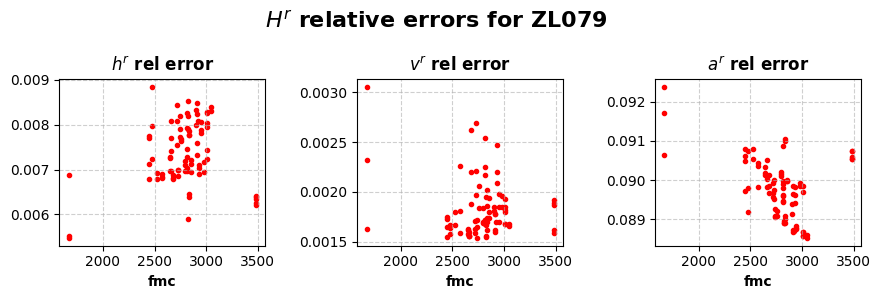

In [155]:
# fig, ax = plot_hr(data, rot_rrp, rot_mc, fstr)
# fig, ax = plot_hr_res(data, rot_rrp, rot_mc, fstr)
fig, ax = plot_hr_rel_err(data, rot_rrp, rot_mc, fstr)

#### BFGS fits for Left Camera

In [156]:
q_rrp = list(rot_rrp.as_quat())
q_mc_0 = list(rot_mc.as_quat())
left_obj = gen_obj(zl, q_rrp)
x0 = q_mc_0 + [0.1, 0.1, 0.1, 1]
left_res = minimize(left_obj, x0, method="BFGS",
                    options={"gtol":1e-19, "xrtol":1e-19, "maxiter":100})
q_mc_zl_0 = np.array(left_res.x[0:4])/np.linalg.norm(left_res.x[0:4])
q_mc_zl_1 = np.array(left_res.x[4:8])

print(f"Left optimization")
print(f"Final function value:\t{left_res.fun:.6f}")
print(f"Final Jacobian value:\t{np.linalg.norm(left_res.jac):.6f}")
print(f"q_mc_zl_0:\t\t{list(q_mc_zl_0)}")
print(f"q_mc_zl_1:\t\t{list(q_mc_zl_1)}")
print('-'*100)

Left optimization
Final function value:	0.004471
Final Jacobian value:	0.000003
q_mc_zl_0:		[0.4632535543617032, 0.4924771601676269, 0.5361222794325821, 0.5054060670198672]
q_mc_zl_1:		[0.010318088289244364, -0.0007067862464506637, -0.001220684593932352, 1.1051285218541245]
----------------------------------------------------------------------------------------------------


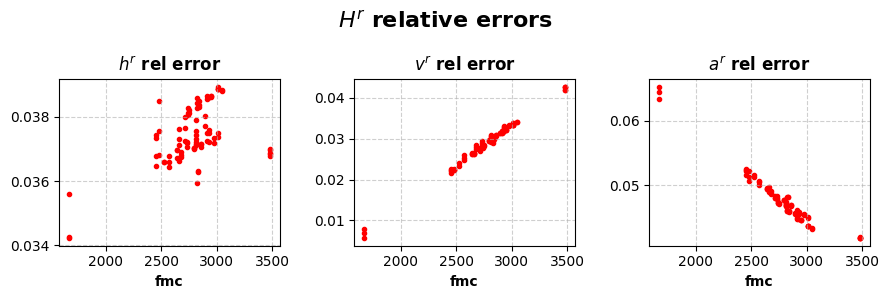

In [157]:
# plot_qmc_hr(zl, q_rrp, q_mc_zl_0, q_mc_zl_1)
# plot_qmc_hr_err(zl, q_rrp, q_mc_zl_0, q_mc_zl_1)
plot_qmc_hr_rel_err(zl, q_rrp, q_mc_zl_0, q_mc_zl_1)

#### Kabsch Fits for Right Camera

In [158]:
q_rrp_0 = [0, 0, 0, 1]
iter, verbose, epsilon = 1000, 200, 1e-17
lambda_h, lambda_v, lambda_a = best_lambda_h, best_lambda_v, best_lambda_a
data = zr
f_str = f"ZR{f_str}"

# here we use the best lambdas to redo the fit and plot the results in Hr space
rot_rrp_rssd = float('inf')
rot_rrp = R.from_quat(q_rrp_0)
for i in range(iter):
  rot_mc, rot_mc_rssd = solve_r_mc(data, rot_rrp, lambda_h, lambda_v, lambda_a)
  rot_rrp, old_rot_rrp_rssd = solve_r_rrp(data, rot_mc, lambda_h, lambda_v, lambda_a)

  if abs(old_rot_rrp_rssd - rot_rrp_rssd) < epsilon:
    print('-' * 150)
    print(f"Convergence critertia met at {i}")
    print(f"rot_mc rssd:{rot_mc_rssd:.5f}\t q_mc={list(rot_mc.as_quat())}")
    print(f"rot_rrp rssd:{rot_rrp_rssd:.5f}\t q_mc={list(rot_rrp.as_quat())}")
    break

  rot_rrp_rssd = old_rot_rrp_rssd

  if (i+1) % verbose == 0:
    print('-' * 150)
    print(f"rot_mc rssd:{rot_mc_rssd:.5f}\t q_mc={list(rot_mc.as_quat())}")
    print(f"rot_rrp rssd:{rot_rrp_rssd:.5f}\t q_mc={list(rot_rrp.as_quat())}")

------------------------------------------------------------------------------------------------------------------------------------------------------
Convergence critertia met at 43
rot_mc rssd:112.23394	 q_mc=[0.47417047872779233, 0.49384497347311523, 0.5277577655198203, 0.5027437122549826]
rot_rrp rssd:112.23393	 q_mc=[7.21932234976242e-05, -0.0004721647951690926, 0.00174047434917696, 0.999998371297466]


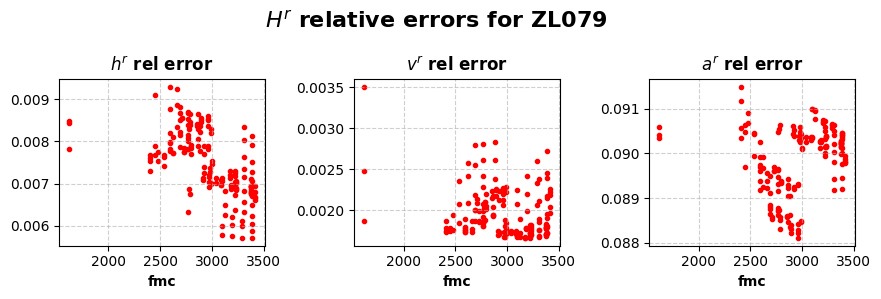

In [159]:
# fig, ax = plot_hr(data, rot_rrp, rot_mc, fstr)
# fig, ax = plot_hr_res(data, rot_rrp, rot_mc, fstr)
fig, ax = plot_hr_rel_err(data, rot_rrp, rot_mc, fstr)

#### BFGS right camera

In [160]:
q_rrp = list(rot_rrp.as_quat())
q_mc_0 = list(rot_mc.as_quat())
right_obj = gen_obj(zr, q_rrp)
x0 = q_mc_0 + [0.1, 0.1, 0.1, 1]
right_res = minimize(right_obj, x0, method="BFGS",
                    options={"gtol":1e-19, "xrtol":1e-19, "maxiter":100})
q_mc_zr_0 = np.array(right_res.x[0:4])/np.linalg.norm(right_res.x[0:4])
q_mc_zr_1 = np.array(right_res.x[4:8])

print(f"Left optimization")
print(f"Final function value:\t{right_res.fun:.6f}")
print(f"Final Jacobian value:\t{np.linalg.norm(right_res.jac):.6f}")
print(f"q_mc_zr_0:\t\t{list(q_mc_zr_0)}")
print(f"q_mc_zr_1:\t\t{list(q_mc_zr_1)}")
print('-'*100)

Left optimization
Final function value:	0.004479
Final Jacobian value:	0.000004
q_mc_zr_0:		[0.5063213354615864, 0.4476889934306583, 0.5721549270241478, 0.4645987622663578]
q_mc_zr_1:		[0.009488453773422225, -0.0066858330848766495, -0.03168998915399058, 1.1635652326313117]
----------------------------------------------------------------------------------------------------


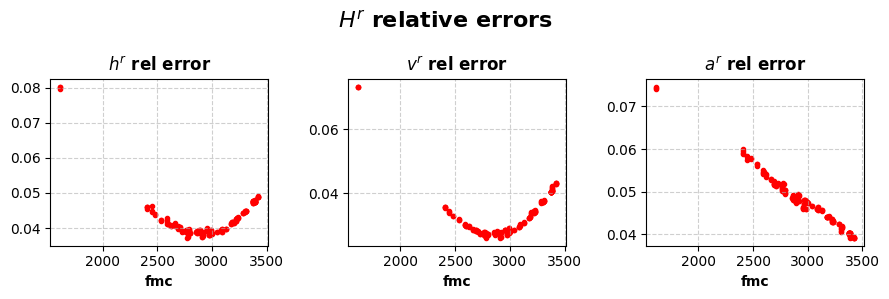

In [161]:
# plot_qmc_hr(zr, q_rrp, q_mc_zr_0, q_mc_zr_1)
# plot_qmc_hr_err(zr, q_rrp, q_mc_zr_0, q_mc_zr_1)
plot_qmc_hr_rel_err(zr, q_rrp, q_mc_zr_0, q_mc_zr_1)